<a href="https://colab.research.google.com/github/BuddhikaRoshan/HemoAi/blob/Buddhika/IT22564122_EfficientNetB0%2C_DenseNet121.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# GOOGLE DRIVE MOUNT
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 1. IMPORT LIBRARIES

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from glob import glob
from PIL import Image
from zipfile import ZipFile

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0, DenseNet121
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

In [ ]:
# 2. DOWNLOAD DATASET
!pip install gdown

import gdown

file_id = "1bW22ebBmxSY9aqOuDvBucNy-fTZfoutF"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "dataset.zip", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1bW22ebBmxSY9aqOuDvBucNy-fTZfoutF
From (redirected): https://drive.google.com/uc?id=1bW22ebBmxSY9aqOuDvBucNy-fTZfoutF&confirm=t&uuid=59e195c4-9b03-4096-87bd-dafdd9dc6d6e
To: /content/dataset.zip
100%|██████████| 4.42G/4.42G [00:55<00:00, 79.5MB/s]


'dataset.zip'

In [ ]:
# 3. EXTRACT DATASET

with ZipFile("dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

dataset_path = "/content/dataset/Leukemia Data Set"

classes = os.listdir(dataset_path)
print("Classes:", classes)

Classes: ['Non Healthy', 'Healthy']


In [ ]:
# 4. PARAMETERS

IMG_SIZE = 128
BATCH_SIZE = 8
EPOCHS = 15
SPLIT = 0.2

In [ ]:
# 5. IMAGE PREPROCESSING


def preprocess_image(img_path):

    img = cv2.imread(img_path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    img = cv2.GaussianBlur(img, (3,3), 0)

    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l,a,b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)

    lab = cv2.merge((l,a,b))
    img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    img = img / 255.0

    return img

In [ ]:
# 6. LOAD DATASET

X = []
Y = []

for i, cat in enumerate(classes):

    images = glob(f"{dataset_path}/{cat}/*.jpg")

    for img_path in images:

        img = preprocess_image(img_path)

        X.append(img)
        Y.append(i)

X = np.array(X)
Y = keras.utils.to_categorical(Y, len(classes))

print("Dataset shape:", X.shape)

Dataset shape: (3000, 128, 128, 3)


In [ ]:
# 7. TRAIN TEST SPLIT

X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y,
    test_size=SPLIT,
    stratify=Y,
    random_state=42
)

In [ ]:
# 8. DATA AUGMENTATION

data_augmentation = keras.Sequential([

    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),

    layers.RandomZoom(
        height_factor=(-0.1,0.1),
        width_factor=(-0.1,0.1)
    ),

    layers.RandomContrast(0.15),
])

In [ ]:
# 9. HYBRID MODEL
# EfficientNetB0 + DenseNet121
# ==========================================

input_layer = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(input_layer)

# -------- EfficientNet --------

efficientnet = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_tensor=x
)

efficientnet.trainable = False

eff_features = GlobalAveragePooling2D()(efficientnet.output)

# -------- DenseNet --------

densenet = DenseNet121(
    include_top=False,
    weights="imagenet",
    input_tensor=x
)

densenet.trainable = False

dense_features = GlobalAveragePooling2D()(densenet.output)

# -------- Merge both networks --------

merged = Concatenate()([eff_features, dense_features])

x = BatchNormalization()(merged)

x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)

x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)

output = Dense(len(classes), activation="softmax")(x)

model = Model(inputs=input_layer, outputs=output)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 128, 128,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 134, 134,  │          0 │ sequential[0][0]  │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 32, 32,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 32, 32,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 32, 32,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 32, 32,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 32, 32,    │          0 │ conv2_block2_0_b

 Total params: 11,719,525 (44.71 MB)

 Trainable params: 627,842 (2.40 MB)

 Non-trainable params: 11,091,683 (42.31 MB)

In [ ]:
# 10. COMPILE MODEL

optimizer = keras.optimizers.Adam(learning_rate=1e-4)

model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# 11. CALLBACKS

callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-6
    )

]

In [ ]:
# 12. TRAIN MODEL

history = model.fit(

    X_train,
    Y_train,

    validation_data=(X_val, Y_val),

    epochs=EPOCHS,
    batch_size=BATCH_SIZE,

    callbacks=callbacks

)

Epoch 1/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 55s 82ms/step - accuracy: 0.8292 - loss: 0.3650 - val_accuracy: 0.9900 - val_loss: 0.0415 - learning_rate: 1.0000e-04
Epoch 2/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 14s 48ms/step - accuracy: 0.9573 - loss: 0.1067 - val_accuracy: 0.9967 - val_loss: 0.0145 - learning_rate: 1.0000e-04
Epoch 3/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - accuracy: 0.9749 - loss: 0.0715 - val_accuracy: 0.9967 - val_loss: 0.0081 - learning_rate: 1.0000e-04
Epoch 4/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.9820 - loss: 0.0536 - val_accuracy: 0.9967 - val_loss: 0.0056 - learning_rate: 1.0000e-04
Epoch 5/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.9806 - loss: 0.0500 - val_accuracy: 0.9967 - val_loss: 0.0044 - learning_rate: 1.0000e-04
Epoch 6/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 16s 53ms/step - accuracy: 0.9739 - loss: 0.0618 - val_accuracy: 1.0000 - val_loss: 0.0029 - learning_rate: 1.0000e-04
Epoch 7/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/ste

19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 158ms/step - accuracy: 1.0000 - loss: 0.0021
Validation Accuracy: 1.0
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 436ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       300
           1       1.00      1.00      1.00       300

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



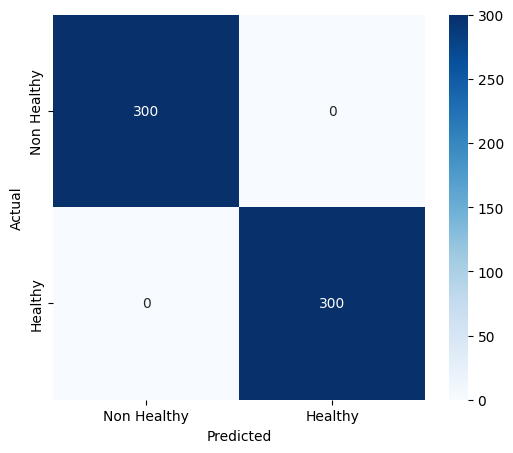

In [ ]:
# 13. EVALUATION

loss, acc = model.evaluate(X_val, Y_val)

print("Validation Accuracy:", acc)

# Predictions

preds = model.predict(X_val)

y_pred = np.argmax(preds, axis=1)
y_true = np.argmax(Y_val, axis=1)

print(classification_report(y_true, y_pred))

# Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=classes,
            yticklabels=classes,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

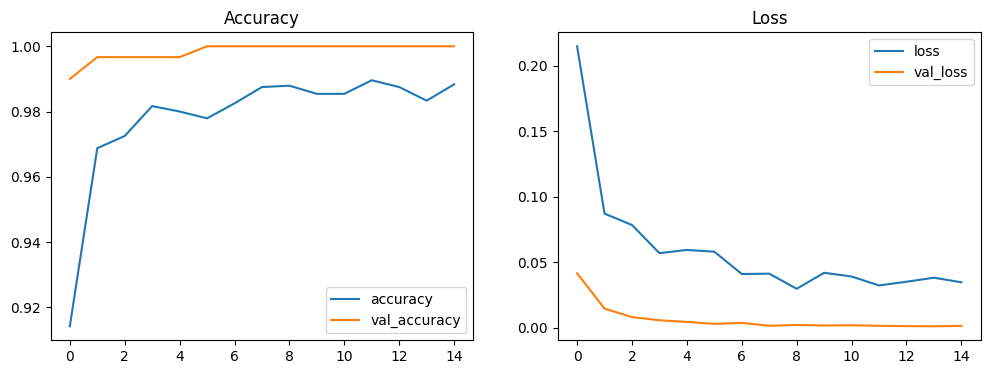

In [ ]:
# 14. TRAINING CURVES

history_df = pd.DataFrame(history.history)

fig, ax = plt.subplots(1,2, figsize=(12,4))

history_df[['accuracy','val_accuracy']].plot(ax=ax[0])
ax[0].set_title("Accuracy")

history_df[['loss','val_loss']].plot(ax=ax[1])
ax[1].set_title("Loss")

plt.show()

In [ ]:
# 15. SAVE MODEL

model.save("leukemia_hybrid_model_1.keras")

print("Hybrid model saved successfully!")

Hybrid model saved successfully!
